In [6]:
from pyspark.sql import SparkSession
import numpy as np

import matplotlib.pyplot as plt

### Centralized Approach

In [7]:
%%time
N = 3 * 10**7
data = np.random.random((N, 2)) * 2 - 1

is_inside_circle = np.vectorize(lambda x, y: 1 if x**2 + y**2 <= 1 else 0)

data_inside_circle = is_inside_circle(data[:, 0], data[:, 1])
count = np.count_nonzero(data_inside_circle)

CPU times: user 5.4 s, sys: 1 s, total: 6.41 s
Wall time: 7.11 s


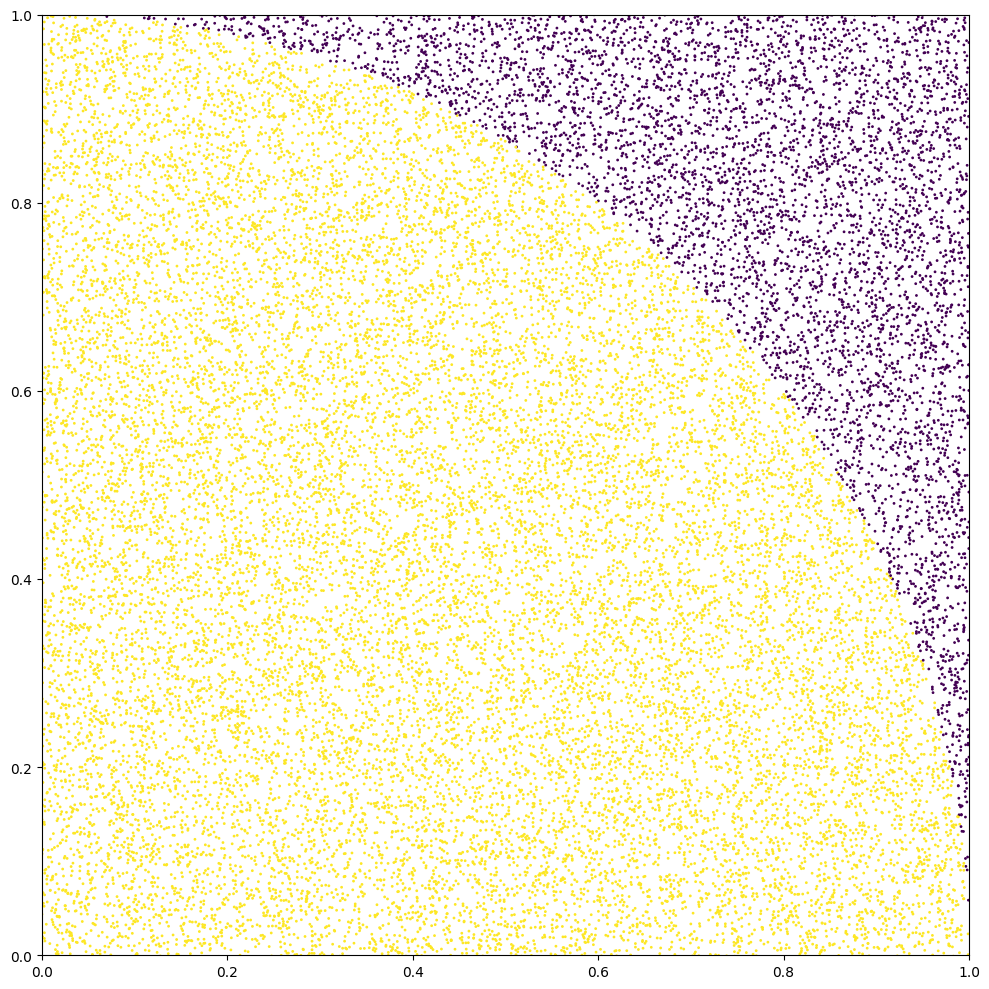

In [8]:
n_samples = 100000  # Subset for convenience

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_xlim((0, 1))
ax.set_ylim((0, 1))

ax.scatter(
    data[:n_samples, 0], data[:n_samples, 1], c=data_inside_circle[:n_samples], s=1
)

plt.tight_layout()
plt.show()

In [9]:
print(f"Pi is roughly: {(4.0 * count / len(data)):.6f}")

Pi is roughly: 3.141386



### PySpark Approach

In [10]:
from pyspark.sql.functions import rand, col, lit
import time
import seaborn as sns
import pandas as pd

In [11]:
spark = (
    SparkSession.builder.appName("SparkDemo")
    .master("local[*]")
    .config("spark.executor.instances", "2")
    .config("spark.executor.memory", "2g")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)

sc = spark.sparkContext

In [12]:
%%time
# Create an RDD of dummy indices, then map to random points
points = (
        spark.range(N)
        .repartition(4)  # set the number of partitions
        .withColumn("x", rand())
        .withColumn("y", rand())
    )

# Count points that lie inside the unit circle
inside = points.filter((col("x") ** 2 + col("y") ** 2) <= 1).count()
pi_est = 4.0 * inside / N

print(f"Pi is roughly {pi_est:.6f}")

Pi is roughly 3.141213
CPU times: user 6.93 ms, sys: 3.09 ms, total: 10 ms
Wall time: 7.38 s


In [13]:
def run_pi_estimate(spark: SparkSession, num_points: int, partitions: int) -> float:
    """
    Approximate π using the Monte‑Carlo method.

    Parameters
    ----------
    spark : SparkSession
        Active Spark session.
    num_points : int
        Total number of random points to generate.
    partitions : int
        Number of partitions to use for the DataFrame.

    Returns
    -------
    float
        Estimated value of π.
    """
    # Create a DataFrame with `num_points` rows
    df = (
        spark.range(num_points)
        .repartition(partitions)  # set the number of partitions
        .withColumn("x", rand())
        .withColumn("y", rand())
    )

    # Count points that lie inside the unit circle
    inside = df.filter((col("x") ** 2 + col("y") ** 2) <= 1).count()

    # π ≈ 4 * (points inside circle) / (total points)
    return 4.0 * inside / num_points

In [20]:
N = 3 * 10**7
runs = 10
TRUE_PI = 3.141592653589793

In [21]:
from itertools import product


partition_counts = [2, 4, 8]
results = []  # will store dicts for each run

print(f"===== Running Monte‑Carlo π estimation =====")
print(f"Total points per run  : {N:,}")
print(f"Number of repetitions : {runs}\n")

# Loop over partition counts & repetitions
for run_idx, partitions in product(range(1, runs + 1), partition_counts):
    start = time.perf_counter()
    pi_est = run_pi_estimate(spark, N, partitions)
    elapsed = time.perf_counter() - start
    error = abs(pi_est - TRUE_PI)

    results.append(
        {
            "partitions": partitions,
            "run": run_idx,
            "pi_estimate": pi_est,
            "error": error,
            "runtime_sec": elapsed,
        }
    )

    print(
        f"Part={partitions:2d}  Run={run_idx:2d}  "
        f"π={pi_est:.8f}  Err={error:.8e}  "
        f"t={elapsed:.4f}s"
    )

===== Running Monte‑Carlo π estimation =====
Total points per run  : 30,000,000
Number of repetitions : 10



Part= 2  Run= 1  π=3.14176787  Err=1.75213077e-04  t=2.8702s


Part= 4  Run= 1  π=3.14166000  Err=6.73464102e-05  t=2.7242s


Part= 8  Run= 1  π=3.14170173  Err=1.09079744e-04  t=3.9372s


Part= 2  Run= 2  π=3.14215867  Err=5.66013077e-04  t=3.4854s


...

Part= 4  Run= 9  π=3.14202907  Err=4.36413077e-04  t=2.2679s


Part= 8  Run= 9  π=3.14170827  Err=1.15613077e-04  t=2.7437s


Part= 2  Run=10  π=3.14135587  Err=2.36786923e-04  t=2.8281s


Part= 4  Run=10  π=3.14121333  Err=3.79320256e-04  t=2.4541s


Part= 8  Run=10  π=3.14176907  Err=1.76413077e-04  t=2.3826s


In [22]:
# Compute variance of the estimates for each partition count
variance_table = []
for partitions in partition_counts:
    estimates = [r["pi_estimate"] for r in results if r["partitions"] == partitions]
    var = np.var(estimates, ddof=1)  # sample variance
    mean_err = np.mean([abs(e - TRUE_PI) for e in estimates])

    variance_table.append(
        {
            "partitions": partitions,
            "estimate_variance": var,
            "mean_error": mean_err,
        }
    )

In [23]:
results_df = pd.DataFrame(results)

<Axes: ylabel='error'>

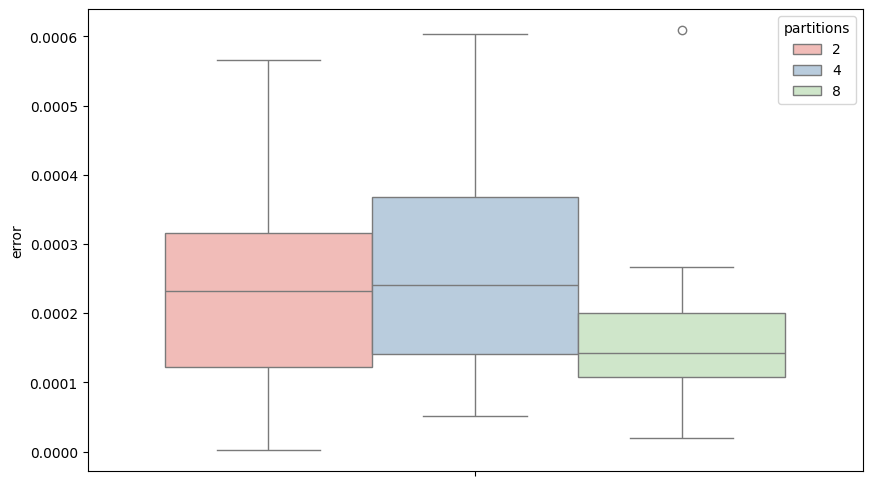

In [24]:
_, ax = plt.subplots(1, 1, figsize=(10, 6))

sns.boxplot(
    data=results_df,
    y="error",
    hue="partitions",
    palette="Pastel1",
    ax=ax,
)

In [ ]:
#  Variance table
print("--- Variance / Mean Error per Partition Count ---")
print(f"{'Partitions':>10} {'Var(π)':>12} {'Mean Error':>12}")
for vt in variance_table:
    print(
        f"{vt['partitions']:10d} {vt['estimate_variance']:12.2e} {vt['mean_error']:12.2e}"
    )